# Lattice Dynamics via the Dynamical Matrix

A direct numerical realization of the derivation we built on the board — from the
harmonic Hamiltonian to the phonon dispersion $\omega(q)$ — with **no time-stepping**.
This is lattice dynamics, *not* MD: we diagonalize once per $q$.

**The chain of logic (recap):**

$$
\underbrace{H'=\tfrac12\sum_{i}M_i\dot u_i^2+\tfrac12\sum_{ij}u_i\,\Phi_{ij}\,u_j}_{\text{harmonic }H}
\;\Rightarrow\;
\underbrace{M_k\ddot u_{kl}=-\sum_{k'l'}\Phi(kl,k'l')\,u_{k'l'}}_{\text{classical EOM (generalized Hooke)}}
$$

Plane-wave ansatz $u_{kl}=u_{k0}\,e^{i(q\cdot R_l-\omega t)}$. The $e^{-i\omega t}$ is common
to every term and cancels; the **relative** phase $e^{iq\cdot R_m}$ (with $R_m=R_{l'}-R_l$)
survives and carries the $q$-dependence — this is what makes $\omega$ depend on $q$
(i.e. produces dispersion):

$$
M_k\,\omega^2\,u_{k0}=\sum_{k',m}\Phi(k0,k'm)\,e^{iq\cdot R_m}\,u_{k'0}.
$$

**Mass-modified Fourier transform** — two cosmetic moves that turn this into a clean
standard eigenvalue problem:

1. *Fourier part*: $\;\tilde\Phi_{kk'}(q)=\sum_m\Phi(k0,k'm)\,e^{iq\cdot R_m}$ (packs the
   whole real-space neighbour sum into one $q$-matrix).
2. *Mass part*: divide symmetrically by $\sqrt{M_kM_{k'}}$ so the matrix is **Hermitian**
   (guarantees real $\omega^2$):

$$
\boxed{\,D_{kk'}(q)=\frac{1}{\sqrt{M_kM_{k'}}}\sum_m\Phi(k0,k'm)\,e^{iq\cdot R_m}\,}
\qquad\Rightarrow\qquad
\boxed{\;\det\!\big|D(q)-\omega^2 I\big|=0\;}
$$

Eigenvalues $\omega^2(q)$ = phonon branches (dispersion); eigenvectors = polarization
vectors (mass-weighted). We build $D(q)$ straight from force constants and diagonalize —
that's the whole simulation.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.dpi": 110, "font.size": 11})

## The general builder

We describe a 1-D crystal by its **springs**. A spring `(i, j, m, k)` is a Hooke coupling
of stiffness $k$ between atom $i$ in the reference cell $0$ and atom $j$ in cell $m$.
It contributes $\tfrac12 k\,(u_{j,m}-u_{i,0})^2$ to the potential, so its force-constant
contributions are:

- $+k$ on each endpoint's on-site (diagonal) term — this is where the **acoustic sum rule**
  $\Phi_{ii}=-\sum_{j\ne i}\Phi_{ij}$ is enforced automatically;
- $-k$ on the cross terms, carrying the phase $e^{\pm iq R_m}$.

List each unique bond **once**. The routine below builds $D(q)$ exactly as boxed above.


In [ ]:
def build_D(q, masses, springs, a):
    """Mass-modified Fourier-transformed dynamical matrix D(q) for a 1-D chain.

    q       : wavevector (scalar)
    masses  : list/array of basis-atom masses, length n
    springs : list of (i, j, m, k). Spring of stiffness k between atom i in
              cell 0 and atom j in cell m. Each unique bond listed ONCE.
    a       : lattice constant
    Returns : n x n complex Hermitian matrix D(q).
    """
    n = len(masses)
    D = np.zeros((n, n), dtype=complex)
    for (i, j, m, k) in springs:
        # on-site (self) restoring terms -> enforces the acoustic sum rule
        D[i, i] += k
        D[j, j] += k
        # inter-site couplings carry the relative-position phase e^{i q R_m}
        D[i, j] += -k * np.exp(1j * q * m * a)
        D[j, i] += -k * np.exp(-1j * q * m * a)
    # symmetric mass weighting  ->  Hermitian D  ->  real omega^2
    D /= np.sqrt(np.outer(masses, masses))
    return D


def dispersion(masses, springs, a, qs):
    """Diagonalize D(q) across a q-path. Returns (omega, polarizations).
    omega[iq, branch]; pol[iq, :, branch] are mass-weighted eigenvectors."""
    n = len(masses)
    omega = np.zeros((len(qs), n))
    pol = np.zeros((len(qs), n, n), dtype=complex)
    for iq, q in enumerate(qs):
        w2, W = np.linalg.eigh(build_D(q, masses, springs, a))  # ascending, Hermitian
        omega[iq] = np.sqrt(np.clip(w2, 0, None))               # clip tiny negatives (numerical)
        pol[iq] = W
    return omega, pol

## Part 1 — Monatomic chain (sanity check)

One atom of mass $M$ per cell, nearest-neighbour springs $k$. Only one bond to list:
atom 0 (cell 0) $\leftrightarrow$ atom 0 (cell 1). This is a $1\times1$ "matrix", so it's
the cleanest possible test. The known answer is

$$\omega(q)=2\sqrt{k/M}\,\bigl|\sin(qa/2)\bigr|,$$

a single **acoustic** branch with $\omega\to0$ as $q\to0$ (the sum rule at work).


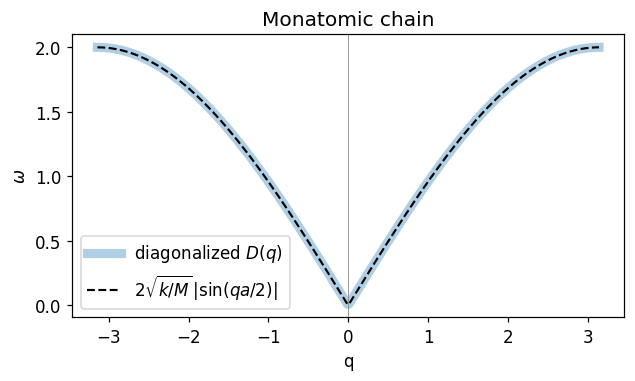

max |numeric - analytic| = 3.3115871156397247e-15


In [3]:
M, k, a = 1.0, 1.0, 1.0
springs_mono = [(0, 0, 1, k)]           # single nearest-neighbour bond
qs = np.linspace(-np.pi/a, np.pi/a, 400)

omega, _ = dispersion([M], springs_mono, a, qs)
omega_exact = 2*np.sqrt(k/M)*np.abs(np.sin(qs*a/2))

fig, ax = plt.subplots(figsize=(6, 3.6))
ax.plot(qs, omega[:, 0], lw=6, alpha=0.35, label="diagonalized $D(q)$")
ax.plot(qs, omega_exact, 'k--', lw=1.4, label=r"$2\sqrt{k/M}\,|\sin(qa/2)|$")
ax.set_xlabel("q"); ax.set_ylabel(r"$\omega$"); ax.set_title("Monatomic chain")
ax.axvline(0, color='gray', lw=.5); ax.legend(); plt.tight_layout(); plt.show()

print("max |numeric - analytic| =", np.max(np.abs(omega[:,0]-omega_exact)))

## Part 2 — Diatomic chain (the real thing)

Two masses $M_1, M_2$ alternating, spring $k$. Now the basis has two atoms, so $D(q)$ is
a genuine $2\times2$ matrix and the $\sqrt{M_1M_2}$ mass-weighting actually does something.
Two bonds: intra-cell $(0\!\to\!1,\,m{=}0)$ and inter-cell $(1\!\to\!0,\,m{=}1)$.

Diagonalizing gives **two branches**:

$$\omega_\pm^2 = k\Big(\tfrac1{M_1}+\tfrac1{M_2}\Big)\pm k\sqrt{\Big(\tfrac1{M_1}+\tfrac1{M_2}\Big)^2-\tfrac{4\sin^2(qa/2)}{M_1M_2}}$$

- lower ($-$): **acoustic** — $\omega\to0$ at $q\to0$, atoms move in phase;
- upper ($+$): **optical** — finite $\omega$ at $q\to0$, atoms move out of phase;
- a **gap** opens at the zone boundary $q=\pi/a$ between $\sqrt{2k/M_2}$ and $\sqrt{2k/M_1}$.


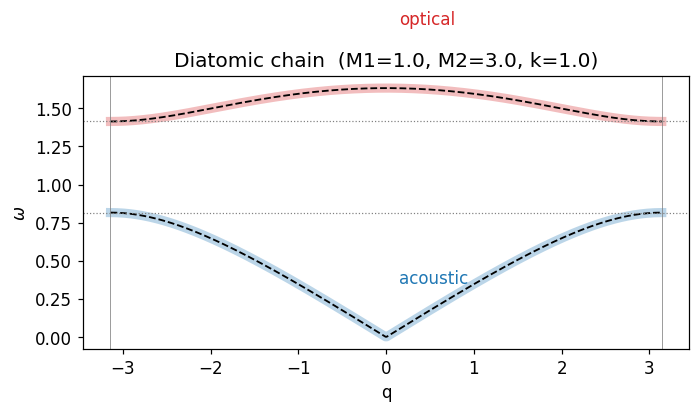

zone-boundary gap: [0.8165, 1.4142]
dashed = analytic, thick = diagonalized D(q)  -> they overlap


In [4]:
M1, M2, k, a = 1.0, 3.0, 1.0, 1.0
masses = [M1, M2]
springs_di = [(0, 1, 0, k), (1, 0, 1, k)]
qs = np.linspace(-np.pi/a, np.pi/a, 500)

omega, pol = dispersion(masses, springs_di, a, qs)

def analytic_di(q):
    s = np.sin(q*a/2)**2
    base = k*(1/M1 + 1/M2)
    disc = k*np.sqrt((1/M1 + 1/M2)**2 - 4*s/(M1*M2))
    return np.sqrt(base - disc), np.sqrt(base + disc)
ac_ex, op_ex = np.array([analytic_di(q) for q in qs]).T

fig, ax = plt.subplots(figsize=(6.4, 4))
ax.plot(qs, omega[:, 0], lw=6, alpha=0.30, color='C0')
ax.plot(qs, omega[:, 1], lw=6, alpha=0.30, color='C3')
ax.plot(qs, ac_ex, 'k--', lw=1.2); ax.plot(qs, op_ex, 'k--', lw=1.2)
ax.text(0.15, 0.35, "acoustic", color='C0')
ax.text(0.15, 2.05, "optical", color='C3')
# gap markers at zone boundary
ax.axhline(np.sqrt(2*k/M2), color='gray', ls=':', lw=.8)
ax.axhline(np.sqrt(2*k/M1), color='gray', ls=':', lw=.8)
ax.axvline(np.pi/a, color='gray', lw=.5); ax.axvline(-np.pi/a, color='gray', lw=.5)
ax.set_xlabel("q"); ax.set_ylabel(r"$\omega$")
ax.set_title(f"Diatomic chain  (M1={M1}, M2={M2}, k={k})")
plt.tight_layout(); plt.show()

print("zone-boundary gap: [%.4f, %.4f]" % (np.sqrt(2*k/M2), np.sqrt(2*k/M1)))
print("dashed = analytic, thick = diagonalized D(q)  -> they overlap")

## Part 3 — What a mode *looks like* (visualizing eigenvectors)

A phonon mode is just an eigenvector of $D(q)$. The physical displacement of atom
$\alpha$ in cell $n$ is

$$u_\alpha(n,t)=\mathrm{Re}\!\left[\frac{w_\alpha}{\sqrt{M_\alpha}}\,e^{i(qna-\omega t)}\right],$$

where $w$ is the (mass-weighted) eigenvector. Dividing by $\sqrt{M_\alpha}$ converts it
back to a real displacement. Below we freeze several time snapshots ("strobe") of the
**acoustic** vs **optical** mode at the same $q$ — the classic in-phase vs out-of-phase
picture. This is the honest, cheap way to "see the ions move": no dynamics simulation,
just plotting an eigenvector.


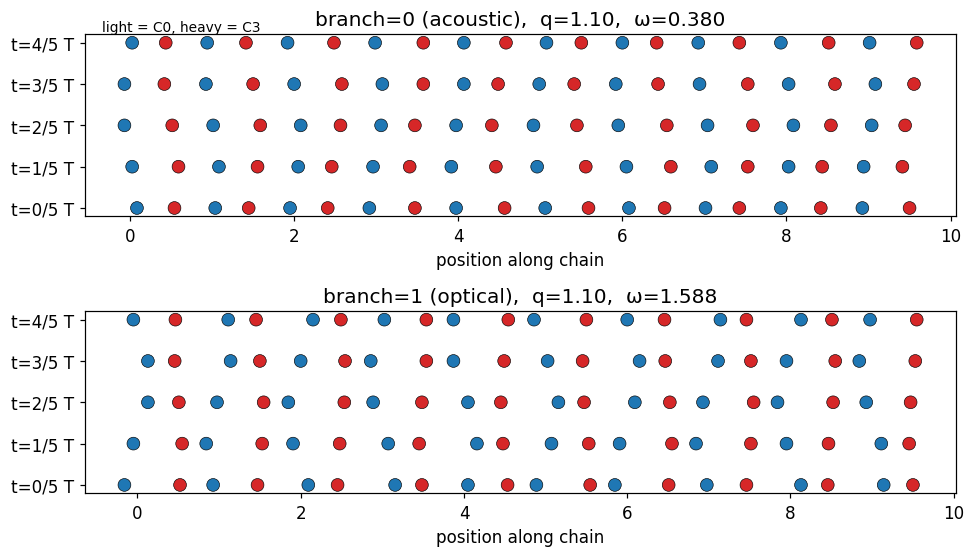

In [5]:
def strobe(masses, springs, a, q, branch, Ncells=10, amp=0.18, nframes=5, ax=None):
    w2, W = np.linalg.eigh(build_D(q, masses, springs, a))
    omega = np.sqrt(np.clip(w2, 0, None))[branch]
    w = W[:, branch]
    phys = w/np.sqrt(masses)                          # physical amplitudes
    n = len(masses)
    # equilibrium positions: atom alpha of cell j sits at (j + alpha/n)*a
    xeq, types = [], []
    for j in range(Ncells):
        for al in range(n):
            xeq.append((j + al/n)*a); types.append(al)
    xeq = np.array(xeq); types = np.array(types)
    if ax is None:
        _, ax = plt.subplots(figsize=(9, 2.6))
    colors = ['C0', 'C3', 'C2', 'C4']
    T = 2*np.pi/omega if omega > 1e-9 else 1.0
    for f in range(nframes):
        t = f*T/nframes
        u = np.array([np.real(phys[types[i]]*np.exp(1j*(q*xeq[i]-omega*t)))
                      for i in range(len(xeq))])
        y = f*np.ones_like(xeq)                        # stack frames vertically
        ax.scatter(xeq + amp*u, y, s=70,
                   c=[colors[t] for t in types], edgecolor='k', linewidth=.4, zorder=3)
    ax.set_yticks(range(nframes))
    ax.set_yticklabels([f"t={f}/{nframes} T" for f in range(nframes)])
    ax.set_xlabel("position along chain")
    ax.set_title(f"branch={branch} ({'acoustic' if branch==0 else 'optical'}),  "
                 f"q={q:.2f},  ω={omega:.3f}")
    return ax

q_show = 0.35*np.pi/a
fig, axes = plt.subplots(2, 1, figsize=(9, 5.2))
strobe(masses, springs_di, a, q_show, branch=0, ax=axes[0])   # acoustic
strobe(masses, springs_di, a, q_show, branch=1, ax=axes[1])   # optical
axes[0].text(0.02, 1.02, "light = C0, heavy = C3", transform=axes[0].transAxes, fontsize=9)
plt.tight_layout(); plt.show()

**Read it:** in the *acoustic* strobe the two sublattices shift together (long-wavelength
translation of the whole chain); in the *optical* strobe the light and heavy atoms move
against each other within each cell. Same $q$, different eigenvector — different physics.
That's the mode/phonon story made visible.

### Optional: live animation (run this cell)

In [7]:
from matplotlib import animation
from IPython.display import HTML

def animate_mode(masses, springs, a, q, branch, Ncells=12, amp=0.22, frames=60):
    w2, W = np.linalg.eigh(build_D(q, masses, springs, a))
    omega = np.sqrt(np.clip(w2, 0, None))[branch]
    phys = W[:, branch]/np.sqrt(masses)
    n = len(masses)
    xeq, types = [], []
    for j in range(Ncells):
        for al in range(n):
            xeq.append((j + al/n)*a); types.append(al)
    xeq = np.array(xeq); types = np.array(types)
    colors = np.array(['C0','C3','C2','C4'])[types]
    fig, ax = plt.subplots(figsize=(9, 1.8))
    ax.set_xlim(-0.5, Ncells*a); ax.set_ylim(-1, 1); ax.set_yticks([])
    ax.set_title(f"{'acoustic' if branch==0 else 'optical'}  q={q:.2f}  ω={omega:.3f}")
    scat = ax.scatter(xeq, np.zeros_like(xeq), s=90, c=colors, edgecolor='k', zorder=3)
    T = 2*np.pi/omega if omega > 1e-9 else 1.0
    def upd(f):
        t = f*T/frames
        u = np.array([np.real(phys[types[i]]*np.exp(1j*(q*xeq[i]-omega*t)))
                      for i in range(len(xeq))])
        scat.set_offsets(np.c_[xeq + amp*u, np.zeros_like(xeq)])
        return scat,
    plt.close(fig)
    return animation.FuncAnimation(fig, upd, frames=frames, interval=60, blit=True)

# Uncomment to view (JS-based, no ffmpeg needed):
HTML(animate_mode(masses, springs_di, a, 0.35*np.pi/a, branch=1).to_jshtml())

## Where this sits in the pipeline

What you just ran is the toy, hand-fed version of **lattice dynamics**: you supplied the
force constants $\Phi$, built $D(q)$, and diagonalized. Two honest caveats and the road ahead:

- **1-D toy vs real Si.** In 3-D the displacements are vectors, so $\Phi$ becomes a
  $3\times3$ tensor per atom pair and $D(q)$ is $3n\times3n$ (for Si, $n=2$ atoms/cell → $6\times6$,
  giving 3 acoustic + 3 optical branches). The machinery is identical — bigger matrices.
- **Where do real $\Phi$ come from?** Not from guessed springs — from first principles via
  **DFPT** (density-functional perturbation theory) or finite displacements in VASP/`phonopy`.
  That's the computational realization of exactly this $D(q)$ for silicon.
- **Why this is *not* MD.** We never integrated Newton's equations in time. MD would
  time-step ions on the *full* (anharmonic) potential — a classical, high-$T$ tool for the
  h.o.t. we deliberately dropped. It's a different method for a different regime, off your
  critical path.
- **Your actual downstream target.** These phonons (ω, polarizations) are the *input* to the
  **electron–phonon coupling** — deformation potentials, Herring–Vogt, and the
  strain-modified scattering that the $\pi_{44}$ shear channel needs. That's the EPW / Poncé
  branch, and it's where the static Herring–Vogt term you've validated meets its dynamic
  ($q\!\to\!0$, oscillating-strain) sibling.

**Try:** change `M1, M2` (set them equal → the gap closes and the optical branch folds back
into acoustic — you recover the monatomic chain on a doubled cell). Or add a second-neighbour
spring to `springs_di` and watch the branches distort.
